<a href="https://colab.research.google.com/github/vijipandian/Employee-Data/blob/main/news_score_97_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
data=pd.read_csv("/content/news.csv",engine="python",on_bad_lines="skip")
data.head(2)

,text,label
0,Gere faults Trump for blurring meaning of 'ref...,1
1,German parties start to find common ground in ...,1


In [10]:
data.shape

(45757, 2)

In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
data.isnull().sum()

,0
text,0
label,0


In [13]:
data.nunique()

,0
text,45757
label,2


In [14]:
data['label'].value_counts()

,count
label,
1,22900
0,22857


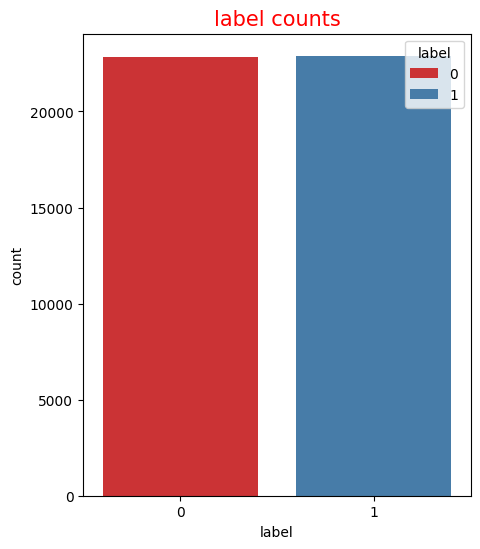

In [15]:
plt.figure(figsize=(5,6))
sns.countplot(data=data,x="label",palette="Set1",hue="label")
plt.title("label counts",fontsize=15,color="red")
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer  #(text data into numbers)

In [18]:
x=data['text']
y=data['label']

In [19]:
tfidf=TfidfVectorizer()
x=tfidf.fit_transform(x)

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [21]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(36605, 162145)
(9152, 162145)
(36605,)
(9152,)


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [23]:
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [24]:
y_pred=model.predict(x_test)

In [25]:
print("accuracy_score:",accuracy_score(y_test, y_pred))
print("classification_report:",classification_report(y_test, y_pred))

accuracy_score: 0.9748688811188811
classification_report:               precision    recall  f1-score   support

           0       0.97      0.98      0.98      4606
           1       0.98      0.97      0.97      4546

    accuracy                           0.97      9152
   macro avg       0.97      0.97      0.97      9152
weighted avg       0.97      0.97      0.97      9152

